# freezing!

In [1]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *

import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.decomposition import PCA
from itertools import permutations, compress, product



%load_ext autoreload 
%autoreload 2
%matplotlib widget

In [2]:
pre=100
post=100
session_path = '../data/vgat2_06062023'
session = MPOptoClass(session_path, post=post)

love


# 1. modelling only climbing data, testing on laser/held out controls
## goal to show: there are a wide set of weights that predict RFA well on ctrl data, and only a subset of these that weight RFA more heavily that do well on laser data

In [62]:
picklepath = '../picklejar/RegSweep/h_list_product_10binsize_10lags_logspace6.pickle'
h_list = pload(picklepath)

weights = np.logspace(0, 6, 15)
weight_combos = list(product(weights, weights))

In [63]:
binsize=10
nlags=10

laser_threshold = 2.26
psth_bounds = copy.deepcopy(session.laser['laser_bounds'])
psth_bounds = psth_bounds[np.array(session.laser['laser_powers']) > laser_threshold, :]
print(psth_bounds.shape)
psth_bounds[:,0] = psth_bounds[:,0] - pre
psth_ctrl_bounds = copy.deepcopy(session.laser['ctrl_bounds'])
psth_ctrl_bounds[:,0] = psth_ctrl_bounds[:,0] - pre


omitLaserBounds = omitBoundInBounds(session.climbing_bounds, psth_bounds)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, psth_ctrl_bounds)

(all_nlags_PCA, all_cut_PCA), PCAObjs = session.format_nlags_PCA(bounds=omitLaserBounds, binsize=10, nlags=10)

(17, 2)


In [64]:
all_laser_nlags, all_laser_cut = session.transformat(PCAObjs, bounds=psth_bounds, binsize=10, nlags=10)
all_laser_cut = all_laser_cut[:, session.num_CFA:]

all_ctrl_nlags, all_ctrl_cut = session.transformat(PCAObjs, bounds=psth_ctrl_bounds, binsize=10, nlags=10)
all_ctrl_cut = all_ctrl_cut[:, session.num_CFA:]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


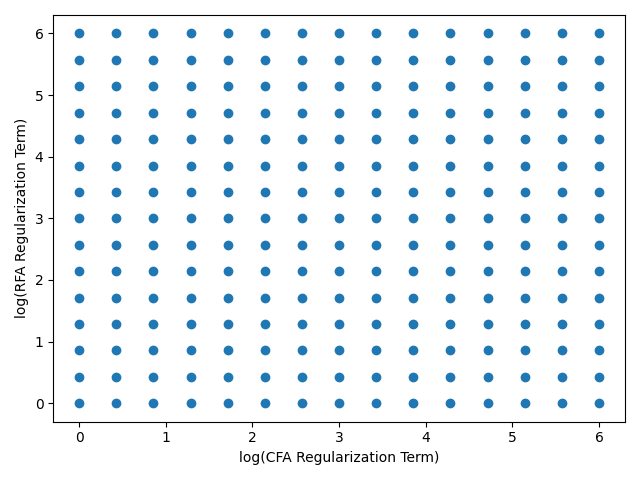

In [65]:
X = np.log10(np.array(weight_combos)[:,0])
Y = np.log10(np.array(weight_combos)[:,1])

fig1, ax1 = plt.subplots()
ax1.scatter(X, Y)
ax1.set_ylabel('log(RFA Regularization Term)')
ax1.set_xlabel('log(CFA Regularization Term)')
fig1.tight_layout()

In [66]:
h_laser_scores = []
h_laser_weights = []

h_ctrl_scores = []
h_ctrl_weights = []
for h in tqdm(h_list):
    y_pred = test_wiener_filter(all_laser_nlags, h)
    y_pred = y_pred[:, session.num_CFA:]
    h_laser_scores.append(weighted_r2(all_laser_cut, y_pred))
    
    h_laser_weights.append(session.weights_per_region(h))
    
    y_pred = test_wiener_filter(all_ctrl_nlags, h)
    y_pred = y_pred[:, session.num_CFA:]
    h_ctrl_scores.append(weighted_r2(all_ctrl_cut, y_pred))
    
    h_ctrl_weights.append(session.weights_per_region(h))
    #temp1, temp2 = relative_input(h, all_nlags_PCA)
    #h_fit_relinputs.append([temp1, temp2])
    #h_fit_scores.append(weighted_r2(all_cut_PCA[:, session.num_CFA:], y_pred[:, session.num_CFA:]))
    
    
h_laser_scores = np.array(h_laser_scores)
h_laser_weights = np.array(h_laser_weights)
h_ctrl_scores = np.array(h_ctrl_scores)
h_ctrl_weights = np.array(h_ctrl_weights)

100%|██████████████████████████████████████████████████████| 225/225 [00:07<00:00, 28.48it/s]


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


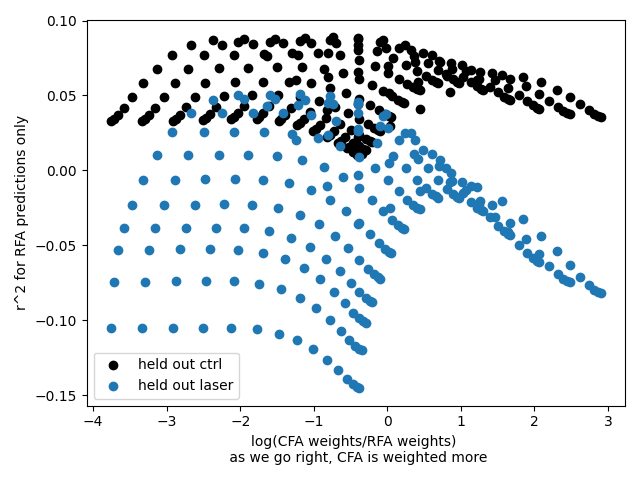

In [67]:
laser_ratio = np.log10(h_laser_weights[:,0] / h_laser_weights[:,1])
ctrl_ratio = np.log10(h_ctrl_weights[:,0] / h_ctrl_weights[:,1])
fig2, ax2 = plt.subplots()
ax2.scatter(ctrl_ratio, h_ctrl_scores, color='black', label='held out ctrl')
ax2.scatter(laser_ratio, h_laser_scores, label='held out laser')
ax2.set_xlabel('log(CFA weights/RFA weights) \n as we go right, CFA is weighted more')
ax2.set_ylabel('r^2 for RFA predictions only')
ax2.legend()

fig2.tight_layout()

In [80]:
np.array(h_list).shape

(225, 3051, 305)

In [83]:
nada, bin_ratio_edges = np.histogram(laser_ratio, bins=25)

h_laser_scores_keep = []
laser_ratio_keep = []

h_ctrl_scores_keep = []
ctrl_ratio_keep = []

good_regs = []
weight_combos = np.array(weight_combos)

h_model_keep = []
h_array = np.array(h_list)

for i in range(bin_ratio_edges.size - 1):
    condition1 = laser_ratio > bin_ratio_edges[i]
    condition2 = laser_ratio < bin_ratio_edges[i+1]
    indices = np.argwhere(np.logical_and(condition1,condition2))
    keep = np.argmax(h_laser_scores[indices])
    temp1 = h_laser_scores[indices]
    temp2 = temp1[keep]
    #print(temp2)
    #print(indices, keep)
    
    h_laser_scores_keep.append(temp2)
    
    temp1 = laser_ratio[indices]
    temp2 = temp1[keep]
    laser_ratio_keep.append(temp2)
    
    temp1 = weight_combos[indices]
    temp2 = temp1[keep]
    good_regs.append(temp2)
    
    #condition1 = ctrl_ratio > bin_ratio_edges[i]
    #condition2 = ctrl_ratio < bin_ratio_edges[i+1]
    #indices = np.argwhere(np.logical_and(condition1,condition2))
    #keep = np.argmax(h_ctrl_scores[indices])
    temp1 = h_ctrl_scores[indices]
    temp2 = temp1[keep]
    
    h_ctrl_scores_keep.append(temp2)
    
    temp1 = ctrl_ratio[indices]
    temp2 = temp1[keep]
    ctrl_ratio_keep.append(temp2)
    
    temp1 = h_array[indices,:,:]
    temp1 = np.squeeze(temp1)
    temp2 = temp1[keep,:,:]
    h_model_keep.append(temp2)
    
    

In [84]:
pdump(h_list[190], '../picklejar/good_model.pickle')


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


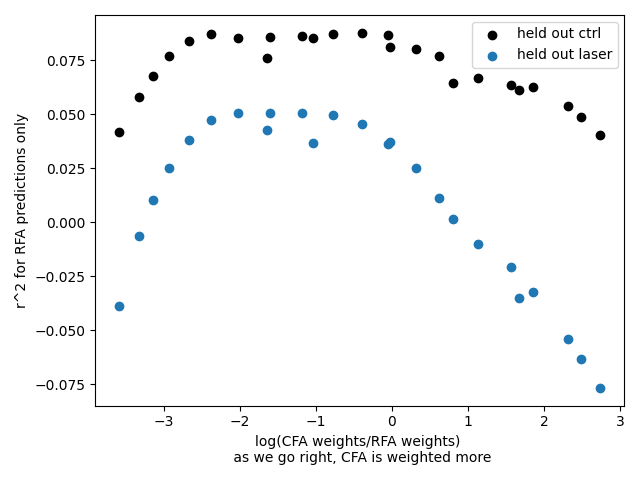

In [20]:
fig3, ax3 = plt.subplots()

ax3.scatter(ctrl_ratio_keep, h_ctrl_scores_keep, color='black', label='held out ctrl')
ax3.scatter(laser_ratio_keep, h_laser_scores_keep, label='held out laser')
ax3.set_xlabel('log(CFA weights/RFA weights) \n as we go right, CFA is weighted more')
ax3.set_ylabel('r^2 for RFA predictions only')
ax3.legend()

fig3.tight_layout()

# 2. What if we include laser data into predictions
## We are including 16 lasers, predicting the held out laser data, then repeating for all lasers.


In [11]:
picklepath='../picklejar/LaserSWSweep/output3.pickle'
output= pload(picklepath)

In [12]:
#0 is regularizaton
#1 is laser_r2
#2 is ctrl_r2
#3 is h
reg_laser_scores = []
reg_ctrl_scores = []
reg_weights = []
for o in output:
    reg_laser_scores.append(o[1])
    reg_ctrl_scores.append(o[2])
    reg_weights.append(session.weights_per_region(o[3]))

reg_laser_scores = np.array(reg_laser_scores)
reg_ctrl_scores = np.array(reg_ctrl_scores)
reg_weights = np.array(reg_weights)
weight_ratios = np.log10(reg_weights[:,0] / reg_weights[:,1])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


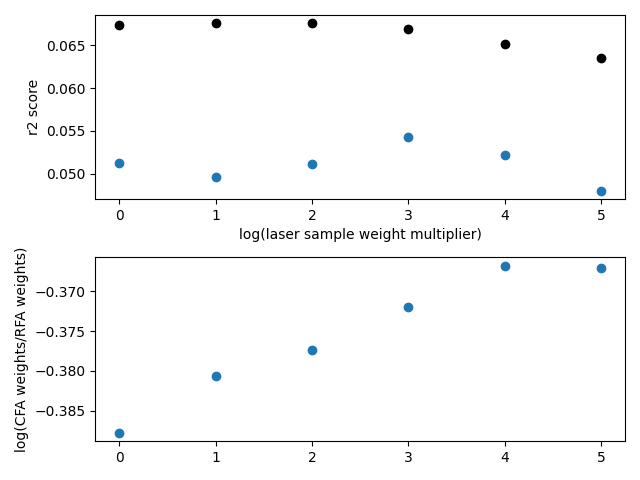

In [13]:
sw_multiplier = np.linspace(0, 5, 6)
fig4, ax4 = plt.subplots(nrows=2)
ax4[0].scatter(sw_multiplier, reg_laser_scores, c='tab:blue', label='held out laser')
ax4[0].scatter(sw_multiplier, reg_ctrl_scores, c='black', label='ctrl')
ax4[0].set_xlabel('log(laser sample weight multiplier)')
ax4[0].set_ylabel('r2 score')

ax4[1].scatter(sw_multiplier, weight_ratios)
ax4[1].set_ylabel('log(CFA weights/RFA weights)')
fig4.tight_layout()

In [14]:
picklepath='../picklejar/LaserRegSweep/fixedoutput.pickle'
output= pload(picklepath)

In [15]:
weights=np.logspace(0,6,5)
weight_combos = list(product(weights, weights))

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


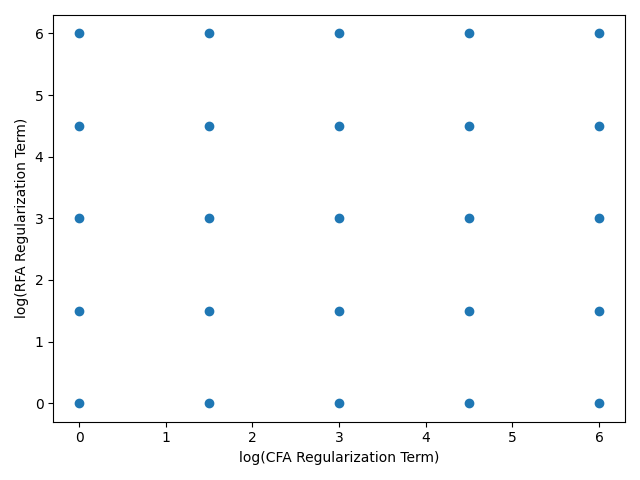

In [16]:
X = np.log10(np.array(weight_combos)[:,0])
Y = np.log10(np.array(weight_combos)[:,1])

fig5, ax5 = plt.subplots()
ax5.scatter(X, Y)
ax5.set_ylabel('log(RFA Regularization Term)')
ax5.set_xlabel('log(CFA Regularization Term)')
fig5.tight_layout()

In [17]:
reg_laser_scores = []
reg_ctrl_scores = []
reg_weights = []
for o in output:
    reg_laser_scores.append(o[1])
    reg_ctrl_scores.append(o[2])
    reg_weights.append(session.weights_per_region(o[3]))

reg_laser_scores = np.array(reg_laser_scores)
reg_ctrl_scores = np.array(reg_ctrl_scores)
reg_weights = np.array(reg_weights)
weight_ratios = np.log10(reg_weights[:,0] / reg_weights[:,1])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


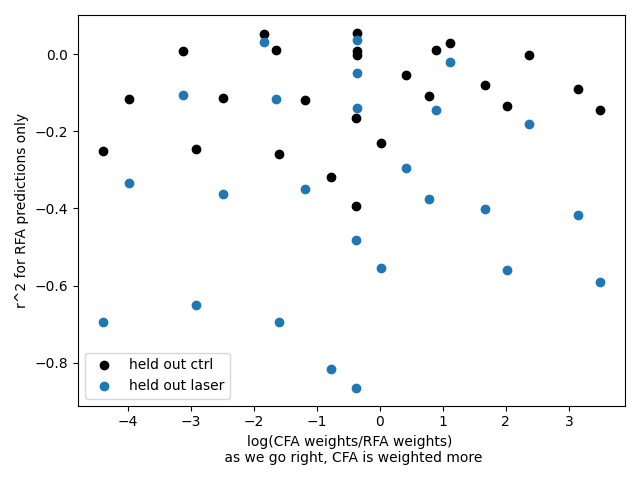

In [18]:
fig6, ax6 = plt.subplots()
ax6.scatter(weight_ratios, reg_ctrl_scores, color='black', label='held out ctrl')
ax6.scatter(weight_ratios, reg_laser_scores, label='held out laser')
ax6.set_xlabel('log(CFA weights/RFA weights) \n as we go right, CFA is weighted more')
ax6.set_ylabel('r^2 for RFA predictions only')
ax6.legend()

fig6.tight_layout()

In [19]:
nada, bin_ratio_edges = np.histogram(weight_ratios, bins=10)

reg_laser_scores_keep = []
reg_ctrl_scores_keep = []
weight_ratios_keep = []

for i in range(bin_ratio_edges.size - 1):
    condition1 = weight_ratios > bin_ratio_edges[i]
    condition2 = weight_ratios < bin_ratio_edges[i+1]
    indices = np.argwhere(np.logical_and(condition1,condition2))
    keep = np.argmax(reg_laser_scores[indices])
    temp1 = reg_laser_scores[indices]
    temp2 = temp1[keep]
    
    reg_laser_scores_keep.append(temp2)
    
    temp1 = reg_ctrl_scores[indices]
    temp2 = temp1[keep]
    
    reg_ctrl_scores_keep.append(temp2)
    
    temp1 = weight_ratios[indices]
    temp2 = temp1[keep]
    weight_ratios_keep.append(temp2)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


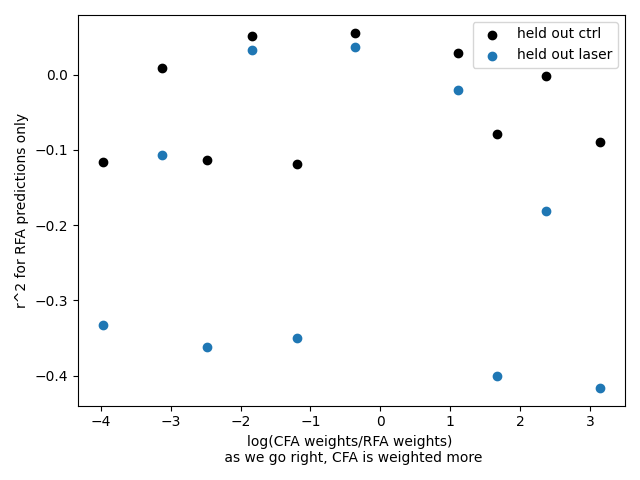

In [20]:
fig7, ax7 = plt.subplots()

ax7.scatter(weight_ratios_keep, reg_ctrl_scores_keep, color='black', label='held out ctrl')
ax7.scatter(weight_ratios_keep, reg_laser_scores_keep, label='held out laser')
ax7.set_xlabel('log(CFA weights/RFA weights) \n as we go right, CFA is weighted more')
ax7.set_ylabel('r^2 for RFA predictions only')
ax7.legend()

fig7.tight_layout()

# half finished --- smoothing other features, getting sense of distribution of ctrl lasers.
# should do: 

# all broken from here on out i think

In [78]:
og_psth_bounds = session.get_highlaser_bounds()
og_psth_ctrl_bounds = session.laser['ctrl_bounds']
og_psth_ctrl_bounds[:,0] = og_psth_ctrl_bounds[:,0] - pre
og_psth_bounds[:,0] = og_psth_bounds[:,0] - pre

omitCtrlBounds = omitBoundInBounds(session.climbing_bounds, og_psth_ctrl_bounds)
psth_newbounds, climbing_duration = reBoundInBounds(omitCtrlBounds, og_psth_bounds)

num_lasers = np.arange(og_psth_bounds.shape[0])
big_laser_true = []
big_laser_predic = []

big_ctrl_true = []
big_ctrl_predic = []

print('now running')
for held_out_num in num_lasers:
    train_psth_bounds = copy.deepcopy(psth_newbounds)
    train_psth_bounds = np.delete(train_psth_bounds, held_out_num, axis=0)
    test_psth_bounds = psth_newbounds[held_out_num, :]
    test_psth_bounds = test_psth_bounds[None, :]


    trainBounds = omitBoundInBounds(omitCtrlBounds, test_psth_bounds)
    train_psth_bounds, duration = reBoundInBounds(trainBounds, train_psth_bounds)
    laser_logical = bounds2Logical(train_psth_bounds, duration=duration)
    laser_logical_trials = unstitchSeams(laser_logical, getSeamsFromBounds(trainBounds, binsize=1))

    sw_list = []
    for trial in laser_logical_trials:
        temp = bin_timeseries(trial, binsize=10)
        sw_list.append(format_single_array(temp))
    sw = (np.hstack(sw_list))[:-1]

    sw = (sw*5)+1
    print('formatting!')
    (all_nlags_PCA, all_cut_PCA), PCA_Objs = session.format_nlags_PCA(bounds=trainBounds, binsize=10, nlags=10)

    #C = np.zeros(all_nlags_PCA.shape[1] + 1)
    #C[1:(session.num_CFA * 10)+1] = weights[0]
    #C[(session.num_CFA * 10)+1:] = weights[1]

    keeper = np.arange(all_nlags_PCA.shape[0])
    prob = copy.deepcopy(sw)
    prob[prob>2] = prob[prob > 2] * 100
    prob = prob/sum(prob)
    keep = np.random.choice(keeper, sw.size//2, False, prob)
    print('fitting!')
                       
    sw = np.ones(keep.size)

    h = weighted_parameter_fit(all_nlags_PCA[keep, :], all_cut_PCA[keep, :], c=50000, sw=sw)

    temp_bounds = og_psth_bounds[held_out_num,:]
    temp_bounds = temp_bounds[None,:]

    laser_input, laser_true = session.transformat(PCA_Objs, bounds=temp_bounds)
    ctrl_input, ctrl_true = session.transformat(PCA_Objs, bounds=og_psth_ctrl_bounds)

    big_laser_true.append(laser_true)
    big_laser_predic.append(test_wiener_filter(laser_input, h))

    big_ctrl_true.append(ctrl_true)
    big_ctrl_predic.append(test_wiener_filter(ctrl_input, h))
    print('finished_laser')
    
    

big_laser_true = np.vstack(big_laser_true)
big_laser_predic = np.vstack(big_laser_predic)
big_ctrl_true = np.vstack(big_ctrl_true)
big_ctrl_predic = np.vstack(big_ctrl_predic)

big_laser_true = big_laser_true[:, session.num_CFA:]
big_laser_predic = big_laser_predic[:, session.num_CFA:]
big_ctrl_true = big_ctrl_true[:, session.num_CFA:]
big_ctrl_predic = big_ctrl_predic[:, session.num_CFA:]

laser_r2 = weighted_r2(big_laser_true, big_laser_predic)
ctrl_r2 = weighted_r2(big_ctrl_true, big_ctrl_predic)
print(f'job complete! laser_r2: {laser_r2}, ctrl_r2: {ctrl_r2}')
    

 

now running
formatting!
fitting!
finished_laser
formatting!
fitting!
finished_laser
formatting!
fitting!
finished_laser
formatting!
fitting!
finished_laser
formatting!
fitting!
finished_laser
formatting!
fitting!
finished_laser
formatting!
fitting!
finished_laser
formatting!
fitting!
finished_laser
formatting!
fitting!
finished_laser
formatting!
fitting!
finished_laser
formatting!
fitting!
finished_laser
formatting!
fitting!
finished_laser
formatting!
fitting!
finished_laser
formatting!
fitting!
finished_laser
formatting!
fitting!
finished_laser
formatting!
fitting!
finished_laser
formatting!
fitting!
finished_laser
job complete! laser_r2: 0.055197020444336976, ctrl_r2: 0.07177628992732911


/home/mirilab/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


<BarContainer object of 2 artists>

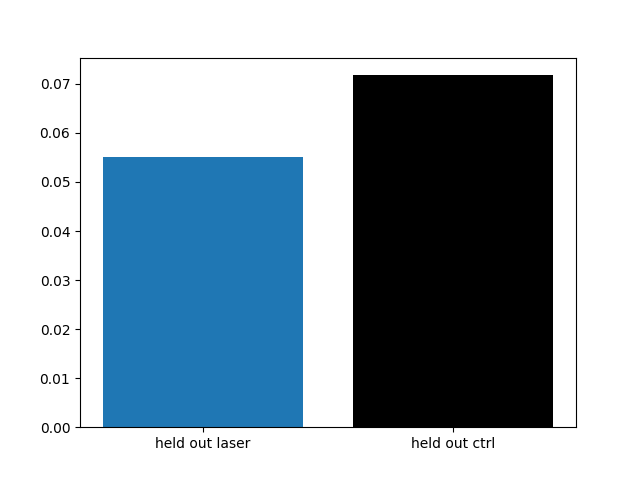

In [83]:
fig4, ax4 = plt.subplots()
ax4.bar(['held out laser', 'held out ctrl'],  [laser_r2, ctrl_r2], color=['tab:blue', 'black'])

In [3]:
og_psth_bounds = session.get_highlaser_bounds()
og_psth_ctrl_bounds = session.laser['ctrl_bounds']
og_psth_ctrl_bounds[:,0] = og_psth_ctrl_bounds[:,0] - pre
og_psth_bounds[:,0] = og_psth_bounds[:,0] - pre

omitCtrlBounds = omitBoundInBounds(session.climbing_bounds, og_psth_ctrl_bounds)
psth_newbounds, climbing_duration = reBoundInBounds(omitCtrlBounds, og_psth_bounds)

In [18]:
(all_nlags, all_cut), nada = session.format_nlags_PCA(bounds=omitCtrlBounds, binsize=10, nlags=10)
(all_nlags_smooth, all_cut_smooth), nada = session.format_nlags_PCA_smooth(bounds=omitCtrlBounds, binsize=10, sigma=50, nlags=10)

In [27]:
h_list = smooth_other_features(all_nlags, all_nlags_smooth, all_cut, C=50000)

  2%|██▍                                                                                                                                                    | 5/305 [00:43<43:05,  8.62s/it]


KeyboardInterrupt: 

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


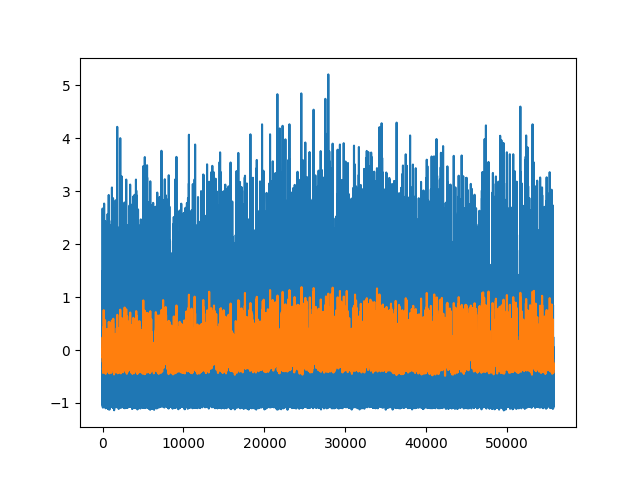

In [28]:
fig, ax = plt.subplots()
ax.plot(all_cut[:,0])
ax.plot(all_cut_smooth[:,0])

In [4]:
output = pload('../picklejar/LaserRegSweep/output.pickle')

In [5]:
def weights_per_region(h, num_CFA=91):
    CFA = np.sum(np.abs(h[1:num_CFA*10+1, num_CFA:]), axis=0)
    RFA = np.sum(np.abs(h[num_CFA*10+1:, num_CFA:]), axis=0)
    
    return np.average(CFA), np.average(RFA)

def relative_input(h, this_input, num_CFA=91):
    bias = h[0,num_CFA:]
    bias = bias[None, :]
    CFA_h = np.vstack((bias, h[1:num_CFA*10+1, num_CFA:]))
    RFA_h = np.vstack((bias, h[num_CFA*10+1:, num_CFA:]))
    
    CFA_drive = np.sum(np.abs(test_wiener_filter(this_input[:, :num_CFA*10], CFA_h)))
    RFA_drive = np.sum(np.abs(test_wiener_filter(this_input[:, num_CFA*10:], RFA_h)))
    
    return CFA_drive, RFA_drive

In [6]:
for o in output:
    print(f'weights {weights_per_region(o[3])}')
    print(f'laser score {o[1]}, ctrl score {o[2]}')
    

weights (3.0046810248883467, 2.6522499975877527)
laser score 0.0039207960744476215, ctrl score 0.049606067586458163
weights (3.0046810248883467, 2.6522499975877527)
laser score 0.0039207960744476215, ctrl score 0.049606067586458163
weights (3.0046810248883467, 2.6522499975877527)
laser score 0.0039207960744476215, ctrl score 0.049606067586458163
weights (3.0046810248883467, 2.6522499975877527)
laser score 0.0039207960744476215, ctrl score 0.049606067586458163
weights (3.0046810248883467, 2.6522499975877527)
laser score 0.0039207960744476215, ctrl score 0.049606067586458163
weights (3.0046810248883467, 2.6522499975877527)
laser score 0.0039207960744476215, ctrl score 0.049606067586458163
weights (3.0046810248883467, 2.6522499975877527)
laser score 0.0039207960744476215, ctrl score 0.049606067586458163
weights (3.0046810248883467, 2.6522499975877527)
laser score 0.0039207960744476215, ctrl score 0.049606067586458163
weights (3.0046810248883467, 2.6522499975877527)
laser score 0.003920796

In [9]:
for o in output:
    print(o[0])

(100.0, 100.0)
(100.0, 1000.0)
(100.0, 10000.0)
(100.0, 100000.0)
(100.0, 1000000.0)
(1000.0, 100.0)
(1000.0, 1000.0)
(1000.0, 10000.0)
(1000.0, 100000.0)
(1000.0, 1000000.0)
(10000.0, 100.0)
(10000.0, 1000.0)
(10000.0, 10000.0)
(10000.0, 100000.0)
(10000.0, 1000000.0)
(100000.0, 100.0)
(100000.0, 1000.0)
(100000.0, 10000.0)
(100000.0, 100000.0)
(100000.0, 1000000.0)
(1000000.0, 100.0)
(1000000.0, 1000.0)
(1000000.0, 10000.0)
(1000000.0, 100000.0)
(1000000.0, 1000000.0)
